## 4.1

In [50]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as cst

x = 1E-3 # Ionization fraction

# Calculate the abundances from Table 1.2
abundance_hydrogen = 12 # by definition
abundance_carbon = 12+np.log10(250*0.1/910630) # table1.2 *0.1 for 10% of the abundance
abundance_oxygen = 12+np.log10(550*0.1/910630) # table1.2 *0.1 for 10% of the abundance

print(abundance_carbon)
print(abundance_oxygen)

7.438598054968874
7.7810207357910794


We can now compute the cooling functions for [CII], [OI], and $\mathrm{Ly}\alpha$. The temperature input MUST be in Kelvin, and the output will be in the correct units of $\mathrm{erg\,cm^3\,s^{-1}}$.

In [58]:
def cooling_CII_e(T,abundance_carbon):
    return 3.1*(x/1E-3)*(T/100)**(-0.5)*np.exp(-91.2/T)*(1E-27)*(10**(abundance_carbon-12))/(2.7E-4) # 1.38 assumes the ratio n_C/n_H to be 2.7E-4
def cooling_CII_H(T,abundance_carbon):
    return 5.2*(T/100)**(0.13)*np.exp(-91.2/T)*(1E-27)*(10**(abundance_carbon-12))/(2.7E-4) # 1.38 assumes the ratio n_C/n_H to be 2.7E-4
def cooling_OI(T,abundance_oxygen):
    return 4.1*(T/100)**(0.42)*np.exp(-228/T)*(1E-27)*(10**(abundance_oxygen-12))/(6E-4) # 1.38 assumes the ratio n_O/n_H to be 6E-4
def cooling_Lya_e(T):
    return 6E5*(x/1E-3)*(T/1000)**(-0.5)*np.exp(-1.18E5/T)*(1E-27)

We can now use the abundances calculated and compute the total cooling function:

In [59]:
def cooling_func(T,abundance_carbon,abundance_oxygen):
    CII = (cooling_CII_e(T,abundance_carbon)+cooling_CII_H(T,abundance_carbon))
    OI = cooling_OI(T,abundance_oxygen)
    Lya = cooling_Lya_e(T)
    return CII + OI + Lya, {r"[CII]$\lambda 158\mathrm{\mu m}$":CII,
                            r"[OI]$\lambda 63\mathrm{\mu m}$":OI,
                            r"$\mathrm{Ly \alpha}$":Lya}

And finally, we can now plot it like Figure 1.10:

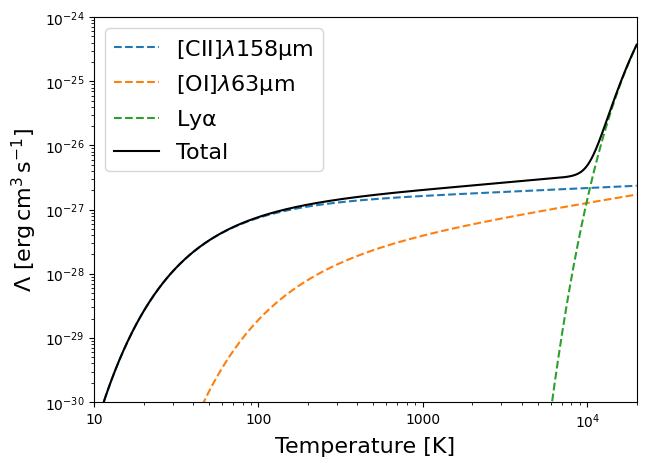

In [60]:
Ts = np.logspace(np.log10(10),np.log10(20000),1000)
cooling_total, cooling_funcs = cooling_func(Ts,abundance_oxygen,abundance_carbon)
plt.figure(figsize=(7,5))
ax = plt.subplot(111)
for c_func in cooling_funcs.keys():
    ax.plot(Ts,cooling_funcs[c_func],ls="--",marker="None",label=c_func)
ax.plot(Ts,cooling_total,ls="-",marker="None",color="black",label="Total")
ax.set_xlabel(r"Temperature [K]", fontsize=16)
ax.set_ylabel(r"$\Lambda$ [$\mathrm{erg\, cm^{3}\,s^{-1}}$]", fontsize=16)
ax.legend(fontsize=16)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10,20000)
ax.set_ylim(1E-30,1E-24)
ax.set_xticks([10,100,1000,1E4],labels=["10","100","1000",r"$10^4$"])
plt.show()

## 4.2

We now want to consider photoelectric heating of dust, and its dependence on metallicity. Equation 1.33 is
$$G_{pe} \sim 2\cdot 10^{-26} \, \mathrm{erg \, s^{-1}}$$
But we can scale it with metallicity, knowing that the heating gain is proportional to

$$G \propto n_\text{ionizing photons}\cdot n_\text{dust particles} \cdot \sigma_{dust-photon}$$
And we could expand this equation
$$G \propto \int_{\nu=5\mathrm{eV}/h}^{\infty}n_{\text{photons},\nu} \cdot n_\text{dust particles} \cdot \sigma_{\text{dust-photon},\nu} \mathrm{d}\nu$$
The only metallicity-dependent term in the integral is $n_\text{dust particles}$, which simply goes as
$$n_\text{dust particles} \propto Z$$
And the rest of the integral goes unchanged, so we have the modified equation 1.33:
$$G_{pe}(z) \sim 2Z\cdot 10^{-26} \, \mathrm{erg \, s^{-1}}$$

We are searching for the balance:

$$n_\mathrm{eq}(T) = \frac{G}{\Lambda(T)}$$

We know that there are metallicity dependencies:
$$n_\mathrm{eq}(T,Z) = \frac{G(Z)}{\Lambda(T,Z)}$$

The metallicity dependency in the cooling function is encoded in the abundances we've used so far, so we can simply make a wrapper function to use metallicity instead of abundances, assuming the ratio of Carbon to Oxygen stays the same:

In [ ]:
def get_abundances(Z):
    ism_metallicity = 1-0.7110-0.2736 # from table 1.2
    abundance_carbon = 12+np.log10(250*(Z/ism_metallicity)/910630) # table1.2 *0.1 for 10% of the abundance
    abundance_oxygen = 12+np.log10(550*(Z/ism_metallicity)/910630) # table1.2 *0.1 for 10% of the abundance
    return abundance_carbon, abundance_oxygen

def cooling_function_metallicity(T,Z):
    return cooling_func(T,*get_abundances(Z))

print(get_abundances(0.03))
print(1-0.7110-0.2736)

(np.float64(8.728198588852072), np.float64(9.070621269674279))
0.015400000000000025
